# 09 — Full-scale run: the whole framework on the entire incoming stream

Streams the **entire** incoming period (days 4-10, ~3.0M rows) through the framework via the
single entry point `framework.run_pipeline`, in 50k-row batches. This is the whole-dataset,
end-to-end run.

**Drift reference — the important part.** A naive *fixed* reference (compare every batch to
the day 1-3 origin) flags all incoming data as drift, because (a) days 4-10 naturally differ
from days 1-3 and (b) the KS test is over-powered at 50k rows. The framework instead uses a
**rolling reference** (compare each batch to recent history) with the KS test run on a fixed
moderate sample, and a drift level calibrated against normal clean variation. This run shows
both so the difference is explicit.

LOF is excluded (near-quadratic, does not scale); the runtime anomaly signal is a fast
log-amount z-score. Module 3's model is reported as `missing_risk` (early warning), separate
from the gate.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import pandas as pd, matplotlib.pyplot as plt
import framework as fw
DATA = '../data/HI-Small_Trans.csv'

## (A) Naive fixed reference — expected to over-fire

In [2]:
_, sum_fixed, stats_fixed = fw.run_pipeline(DATA, fw.IBM_CONFIG, batch_size=50_000,
                                            drift_reference='fixed', verbose=True)
print(stats_fixed)

[IBM HI-Small] reference=2076752  incoming=3000485  batch_size=50000  drift_reference=fixed
  batch   0/61  rows=50000  combined=0.497  PASS
  batch  10/61  rows=50000  combined=0.417  PASS
  batch  20/61  rows=50000  combined=0.649  FAIL
  batch  30/61  rows=50000  combined=0.675  FAIL
  batch  40/61  rows=50000  combined=0.218  PASS
  batch  50/61  rows=50000  combined=0.238  PASS
  batch  60/61  rows=485  combined=0.463  PASS
[done] 61 batches, 12 FAIL, 14.0s
{'reference_rows': 2076752, 'incoming_rows': 3000485, 'drift_reference': 'fixed', 'batches': 61, 'fail_batches': 12, 'time_s': 14.0}


## (B) Rolling reference (the fix)

In [3]:
_, sum_roll, stats_roll = fw.run_pipeline(DATA, fw.IBM_CONFIG, batch_size=50_000,
                                          drift_reference='rolling', verbose=True)
print(stats_roll)

[IBM HI-Small] reference=2076752  incoming=3000485  batch_size=50000  drift_reference=rolling
  batch   0/61  rows=50000  combined=0.497  PASS
  batch  10/61  rows=50000  combined=0.371  PASS
  batch  20/61  rows=50000  combined=0.159  PASS
  batch  30/61  rows=50000  combined=0.351  PASS
  batch  40/61  rows=50000  combined=0.265  PASS
  batch  50/61  rows=50000  combined=0.311  PASS
  batch  60/61  rows=485  combined=0.344  PASS
[done] 61 batches, 3 FAIL, 13.7s
{'reference_rows': 2076752, 'incoming_rows': 3000485, 'drift_reference': 'rolling', 'batches': 61, 'fail_batches': 3, 'time_s': 13.7}


## Contrast: how many batches each configuration flags

In [4]:
print('incoming rows processed : %d (fixed) / %d (rolling)'
      % (int(sum_fixed['rows'].sum()), int(sum_roll['rows'].sum())))
print('batches                 : %d' % stats_roll['batches'])
print('FAIL batches  — fixed   : %d / %d  (%.0f%%)'
      % (stats_fixed['fail_batches'], stats_fixed['batches'],
         100*stats_fixed['fail_batches']/stats_fixed['batches']))
print('FAIL batches  — rolling : %d / %d  (%.0f%%)'
      % (stats_roll['fail_batches'], stats_roll['batches'],
         100*stats_roll['fail_batches']/stats_roll['batches']))
print('throughput (rolling)    : %.0f rows/s' % (stats_roll['incoming_rows']/max(stats_roll['time_s'],1)))
sum_roll.head(15)

incoming rows processed : 3000485 (fixed) / 3000485 (rolling)
batches                 : 61
FAIL batches  — fixed   : 12 / 61  (20%)
FAIL batches  — rolling : 3 / 61  (5%)
throughput (rolling)    : 219014 rows/s


,batch,rows,anomaly,drift,missing,combined,decision,missing_risk
0,0,50000,0.000,0.4965,0.0,0.4965,PASS,0.3015
1,1,50000,0.000,0.4170,0.0,0.4170,PASS,0.3879
2,2,50000,0.000,0.2448,0.0,0.2448,PASS,0.3801
3,3,50000,0.000,0.0063,0.0,0.0063,PASS,0.3733
4,4,50000,0.000,0.2647,0.0,0.2647,PASS,0.3081
5,5,50000,0.000,0.2448,0.0,0.2448,PASS,0.3902
6,6,50000,0.002,0.0858,0.0,0.0858,PASS,0.3994
7,7,50000,0.000,0.2117,0.0,0.2117,PASS,0.3990
8,8,50000,0.000,0.2845,0.0,0.2845,PASS,0.3955
9,9,50000,0.000,0.1057,0.0,0.1057,PASS,0.3936


## Per-batch drift score: fixed vs rolling

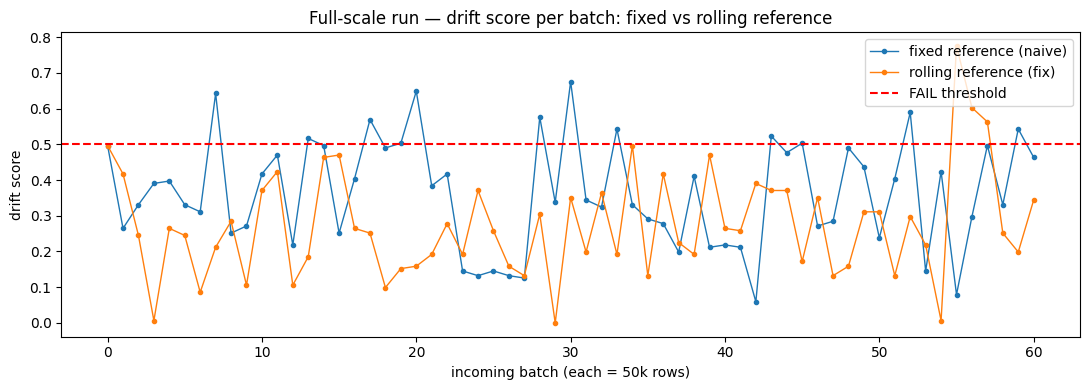

In [5]:
plt.figure(figsize=(11, 4))
plt.plot(sum_fixed['batch'], sum_fixed['drift'], marker='.', linewidth=1, label='fixed reference (naive)')
plt.plot(sum_roll['batch'],  sum_roll['drift'],  marker='.', linewidth=1, label='rolling reference (fix)')
plt.axhline(0.5, color='r', linestyle='--', label='FAIL threshold')
plt.xlabel('incoming batch (each = 50k rows)'); plt.ylabel('drift score')
plt.title('Full-scale run — drift score per batch: fixed vs rolling reference')
plt.legend(); plt.tight_layout()
plt.savefig('../results/fullscale_fixed_vs_rolling.png', dpi=120); plt.show()

## Save the run

In [6]:
sum_fixed.to_csv('../results/fullscale_fixed.csv', index=False)
sum_roll.to_csv('../results/fullscale_rolling.csv', index=False)
print('saved fullscale_fixed.csv and fullscale_rolling.csv')

saved fullscale_fixed.csv and fullscale_rolling.csv


## Reading the results
- The framework processed the **entire** incoming stream (every row, in 50k batches) — the whole-dataset run.
- **Fixed reference** flags a large fraction of batches: the naive baseline conflates natural temporal drift and large-sample test sensitivity with real quality problems.
- **Rolling reference** (compare to recent history, KS on a fixed sample, drift calibrated to normal variation) is discriminating: it passes normal batches and flags only batches whose distribution departs materially from recent data.
- This is the practical difference between a drift gate that always says FAIL and one that is usable in production. The anomaly and missing gates are exercised separately in the ablation (notebook 07).